# 05 — Modelo XGBoost + SHAP (Fase 2)

**Responsable:** Rafael
**Depende de:** `data/processed/dataset_maestro_2019_2025.csv` (ya generado por Juan David)

## Decisiones de diseño (revisar antes de correr)

1. **Resolución/horizonte: horario, día-adelante.** Se predice el precio de bolsa hora por hora,
   usando solo información disponible hasta el cierre del día anterior. Esto mantiene la misma
   granularidad que Prophet (comparabilidad directa en Fase 3) y no se pierde la estacionalidad
   diaria (pico 18-19h) ya caracterizada en 1.4/1.5.

2. **Backtest 2026 — pendiente.** El plan de Fase 1 menciona validar contra el Niño 2026 en la
   ventana ene-ago 2026, pero el dataset maestro solo llega a 2025. Este notebook usa un *holdout*
   cronológico dentro de 2019-2025 (últimos ~2 meses de 2025) para poder entrenar y evaluar ya.
   Cuando el pipeline se extienda con datos 2026 (misma función `descargar_rango_horario_robusto`),
   ese tramo se convierte en el verdadero backtest fuera de muestra — hay un TODO marcado abajo
   donde conectarlo.

3. **Variables exógenas rezagadas, no contemporáneas.** Demanda, generación, embalses y aportes
   se usan con rezago (no el valor de la misma hora que se predice), para que el pronóstico sea
   honesto "día-adelante" y no folletineo, ni tampoco use la generacion que produjo la demanda actual (data leakage). Si el objetivo fuera solo explicativo (SHAP sobre
   qué mueve el precio históricamente, sin pretender pronosticar), se podrían usar en valor
   contemporáneo — cambiar `USE_CONTEMPORANEOUS_EXOG` en la config si prefieren eso.

4. **Alcance de SHAP: importancia global**, según el recorte ya decidido en el doc de estado
   (no exploración exhaustiva por si el tiempo aprieta).

## Antes de correr

- Instalar XGBoost y SHAP en tu entorno (con la ruta completa del python del venv, según el
  gotcha del doc de estado): `C:\...\venv\Scripts\python.exe -m pip install xgboost shap`
- Revisar el diccionario `COLUMN_MAP` en la celda de configuración: los nombres exactos de columna
  del CSV no los tengo confirmados, así que centralizo el mapeo ahí — un solo lugar para ajustar
  si no calzan.

In [36]:
import sys
print(sys.executable)

c:\Users\rafad\Downloads\ProyectoFinal1\xm-spot-price-predictor\venv\Scripts\python.exe


In [37]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)


## 1. Configuración

Un solo lugar para ajustar nombres de columnas y decisiones de diseño.

In [38]:
DATA_PATH = "../data/processed/dataset_maestro_2019_2025.csv"

# Ajustar estos nombres si no coinciden con las columnas reales del CSV.
# (imprimimos df.columns abajo justo después de cargar, para verificar rápido)
COLUMN_MAP = {
    "datetime": "fecha_hora",       # columna de fecha+hora
    "precio": "precio_bolsa",       # target
    "demanda": "demanda",
    "generacion": "generacion_total",
    "embalses": "volumen_util_embalses",
    "aportes": "aportes_hidricos",
    "es_pandemia": "es_pandemia",
    "oni": "oni",
}

USE_CONTEMPORANEOUS_EXOG = False   # ver decisión (3) en la celda de arriba
TEST_MONTHS = 2                    # holdout cronológico: últimos N meses de 2025
VAL_MONTHS = 2                     # validación (early stopping) justo antes del test

RANDOM_STATE = 42


## 2. Carga de datos

In [39]:
df = pd.read_csv(DATA_PATH)

COLUMN_MAP = {
    "datetime": "fecha_hora",          # si ya la pusiste como índice, no se usa más
    "precio": "precio_bolsa",
    "demanda": "demanda",
    "generacion": "generacion",        # ← corregido
    "embalses": "volumen_embalses",    # ← corregido
    "aportes": "aportes_hidricos",
    "es_pandemia": "es_pandemia",
    "oni": "oni",
}

USE_CONTEMPORANEOUS_EXOG = False
TEST_MONTHS = 2
VAL_MONTHS = 2
RANDOM_STATE = 42

In [40]:
df[COLUMN_MAP["datetime"]] = pd.to_datetime(df[COLUMN_MAP["datetime"]])
df = df.sort_values(COLUMN_MAP["datetime"]).reset_index(drop=True)
df = df.set_index(COLUMN_MAP["datetime"])

assert df.index.is_unique, "Hay timestamps duplicados — revisar antes de seguir."
assert df.isna().sum().sum() == 0, "Aparecieron nulos — el doc de estado decía 0 en las 5 fuentes."

df.tail()


,precio_bolsa,demanda,generacion,volumen_embalses,aportes_hidricos,es_pandemia,anio,mes,oni
fecha_hora,,,,,,,,,
2025-12-31 19:00:00,285.30327,10409853.60,10607911.75,1.356455e+10,1.324896e+08,0,2025,12,-0.6
2025-12-31 20:00:00,285.30327,10006764.73,10213687.18,1.356455e+10,1.324896e+08,0,2025,12,-0.6
2025-12-31 21:00:00,285.30327,9464507.63,9659649.64,1.356455e+10,1.324896e+08,0,2025,12,-0.6
2025-12-31 22:00:00,273.59227,8961022.88,9152097.02,1.356455e+10,1.324896e+08,0,2025,12,-0.6
2025-12-31 23:00:00,271.30327,8530472.95,8738531.47,1.356455e+10,1.324896e+08,0,2025,12,-0.6


## 3. Feature engineering

- Calendario (cíclico: hora, día de semana, mes)
- Rezagos del precio (1h, 24h, 168h) — autoregresivo
- Rolling stats del precio (rezagados, sin fuga de información)
- Exógenas rezagadas (o contemporáneas, según `USE_CONTEMPORANEOUS_EXOG`)
- `es_pandemia`, `oni` tal cual (ya vienen listas del cruce de Juan David)


In [41]:
print(df.columns.tolist())

['precio_bolsa', 'demanda', 'generacion', 'volumen_embalses', 'aportes_hidricos', 'es_pandemia', 'anio', 'mes', 'oni']


In [ ]:
feat = pd.DataFrame(index=df.index)

precio = df[COLUMN_MAP["precio"]]
feat["precio"] = precio  # target, se separa más abajo

# --- Calendario cíclico ---
hour = df.index.hour
dow = df.index.dayofweek
month = df.index.month

feat["hour_sin"] = np.sin(2 * np.pi * hour / 24)
feat["hour_cos"] = np.cos(2 * np.pi * hour / 24)
feat["dow_sin"] = np.sin(2 * np.pi * dow / 7)
feat["dow_cos"] = np.cos(2 * np.pi * dow / 7)
feat["month_sin"] = np.sin(2 * np.pi * month / 12)
feat["month_cos"] = np.cos(2 * np.pi * month / 12)
feat["is_weekend"] = (dow >= 5).astype(int)

# --- Rezagos del precio (autoregresivo) ---
feat["precio_lag_1h"] = precio.shift(1)
feat["precio_lag_24h"] = precio.shift(24)
feat["precio_lag_168h"] = precio.shift(168)   # misma hora, semana pasada

# --- Rolling stats del precio, rezagadas 24h para no usar el propio target del día ---
feat["precio_roll_mean_24h"] = precio.shift(24).rolling(24).mean()
feat["precio_roll_std_24h"] = precio.shift(24).rolling(24).std()
feat["precio_roll_mean_168h"] = precio.shift(24).rolling(168).mean()

# --- Exógenas ---
exog_cols = ["demanda", "generacion", "embalses", "aportes"]
lag_h = 0 if USE_CONTEMPORANEOUS_EXOG else 24  # rezago día-adelante si aplica

for c in exog_cols:
    col = df[COLUMN_MAP[c]]
    feat[f"{c}_lag{lag_h}h"] = col.shift(lag_h)

# --- Cambios estructurales ya resueltos por Juan David ---
feat["es_pandemia"] = df[COLUMN_MAP["es_pandemia"]]
feat["oni"] = df[COLUMN_MAP["oni"]]

n_before = len(feat)
feat = feat.dropna()
print(f"Filas: {n_before} -> {len(feat)} tras dropna (arranque de la serie por los rezagos/rolling)")

feat.head()


Filas: 61368 -> 61177 tras dropna (arranque de la serie por los rezagos/rolling)


,precio,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_weekend,precio_lag_1h,precio_lag_24h,precio_lag_168h,precio_roll_mean_24h,precio_roll_std_24h,precio_roll_mean_168h,demanda_lag24h,generacion_lag24h,embalses_lag24h,aportes_lag24h,es_pandemia,oni
fecha_hora,,,,,,,,,,,,,,,,,,,,
2019-01-08 23:00:00,363.88430,-0.258819,0.965926,0.781831,0.623490,0.5,0.866025,0,363.88430,369.71226,318.42310,334.113427,61.440432,340.892668,6814606.51,6859511.61,1.168612e+10,73105400.0,0,1.0
2019-01-09 00:00:00,257.49997,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025,0,363.88430,363.88430,335.52288,333.870595,61.304984,341.163271,6445755.77,6462300.90,1.162660e+10,67340400.0,0,1.0
2019-01-09 01:00:00,249.18697,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025,0,257.49997,310.15330,323.02288,336.369430,58.921344,341.114046,6235994.37,6232447.92,1.162660e+10,67340400.0,0,1.0
2019-01-09 02:00:00,249.18697,0.500000,0.866025,0.974928,-0.222521,0.5,0.866025,0,249.18697,310.15330,295.50888,338.868265,56.321552,341.064821,6085039.17,6112260.50,1.162660e+10,67340400.0,0,1.0
2019-01-09 03:00:00,249.18697,0.707107,0.707107,0.974928,-0.222521,0.5,0.866025,0,249.18697,310.15330,262.02288,341.367100,53.474089,341.015596,6061339.65,6117401.76,1.162660e+10,67340400.0,0,1.0


## 4. Split cronológico (train / val / test)

Holdout temporal, nunca aleatorio — es serie de tiempo. `TEST_MONTHS` finales de 2025 quedan
fuera de todo entrenamiento; `VAL_MONTHS` justo antes se usan solo para early stopping.

**TODO (cuando el dataset se extienda a 2026):** reemplazar este holdout por el tramo real
ene-ago 2026, y usar 2025 completo dentro de train/val — ese es el backtest que de verdad importa
para validar generalización al Niño nuevo.


In [43]:
target_col = "precio"
X_cols = [c for c in feat.columns if c != target_col]

test_start = feat.index.max() - pd.DateOffset(months=TEST_MONTHS)
val_start = test_start - pd.DateOffset(months=VAL_MONTHS)

train = feat[feat.index < val_start]
val = feat[(feat.index >= val_start) & (feat.index < test_start)]
test = feat[feat.index >= test_start]

X_train, y_train = train[X_cols], train[target_col]
X_val, y_val = val[X_cols], val[target_col]
X_test, y_test = test[X_cols], test[target_col]

print(f"train: {train.index.min()} -> {train.index.max()}  ({len(train)} filas)")
print(f"val:   {val.index.min()} -> {val.index.max()}  ({len(val)} filas)")
print(f"test:  {test.index.min()} -> {test.index.max()}  ({len(test)} filas)")


train: 2019-01-08 23:00:00 -> 2025-08-31 22:00:00  (58248 filas)
val:   2025-08-31 23:00:00 -> 2025-10-31 22:00:00  (1464 filas)
test:  2025-10-31 23:00:00 -> 2025-12-31 23:00:00  (1465 filas)


## 5. Baselines (benchmarking, GEFCom / Weron)

Antes de evaluar XGBoost hay que saber contra qué compararlo. Dos baselines estándar en la
literatura de pronóstico de precio de energía:
- **Persistencia (lag-24h):** el precio de mañana a esta hora = el precio de hoy a esta hora.
- **Naive estacional (lag-168h):** el precio de esta hora = el precio de la misma hora, semana pasada.


In [44]:
def metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{label:25s}  MAE={mae:9.2f}  RMSE={rmse:9.2f}  MAPE={mape:6.2f}%")
    return {"label": label, "mae": mae, "rmse": rmse, "mape": mape}

results = []
results.append(metrics(y_test, test["precio_lag_24h"], "Baseline persistencia (lag-24h)"))
results.append(metrics(y_test, test["precio_lag_168h"], "Baseline naive estacional (lag-168h)"))


Baseline persistencia (lag-24h)  MAE=    51.02  RMSE=   101.33  MAPE= 22.51%
Baseline naive estacional (lag-168h)  MAE=    97.35  RMSE=   132.67  MAPE= 41.58%


## 6. Entrenamiento XGBoost

In [45]:
model = xgb.XGBRegressor(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    early_stopping_rounds=50,
    eval_metric="mae",
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"Mejor iteración: {model.best_iteration}")


Mejor iteración: 254


## 7. Evaluación en test (holdout 2025)

In [46]:
y_pred = model.predict(X_test)
results.append(metrics(y_test, y_pred, "XGBoost"))

results_df = pd.DataFrame(results).set_index("label")
results_df


XGBoost                    MAE=    31.38  RMSE=    69.29  MAPE= 12.78%


,mae,rmse,mape
label,,,
Baseline persistencia (lag-24h),51.019447,101.330848,22.508560
Baseline naive estacional (lag-168h),97.353818,132.670737,41.579408
XGBoost,31.380320,69.293391,12.784146


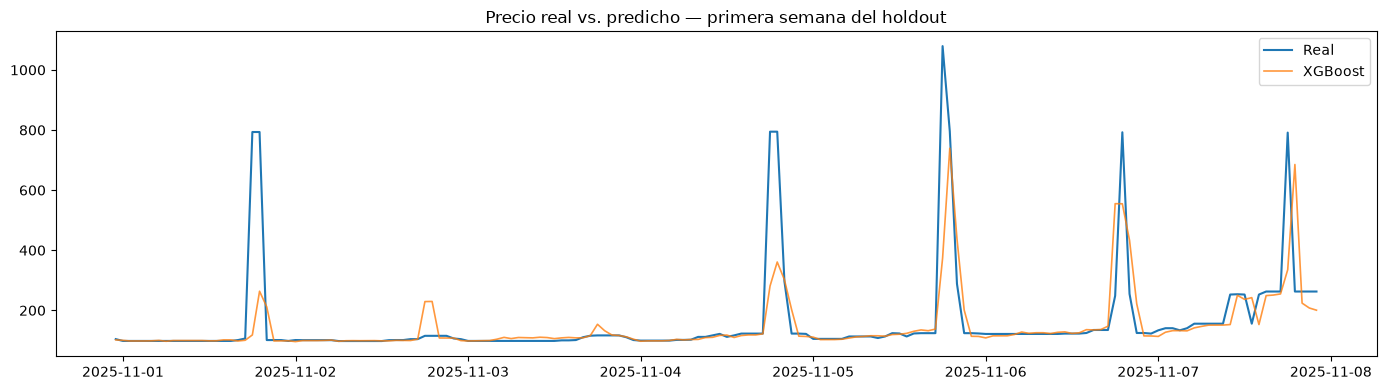

In [47]:
fig, ax = plt.subplots(figsize=(14, 4))
sample = slice(0, 24 * 7)  # primera semana del test, para que se vea el detalle horario
ax.plot(y_test.index[sample], y_test.values[sample], label="Real", linewidth=1.5)
ax.plot(y_test.index[sample], y_pred[sample], label="XGBoost", linewidth=1.2, alpha=0.8)
ax.set_title("Precio real vs. predicho — primera semana del holdout")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Explicabilidad — SHAP (importancia global)

Alcance según lo ya decidido en el doc de estado: importancia global, no exploración exhaustiva
por interacciones ni waterfall por cada caso.


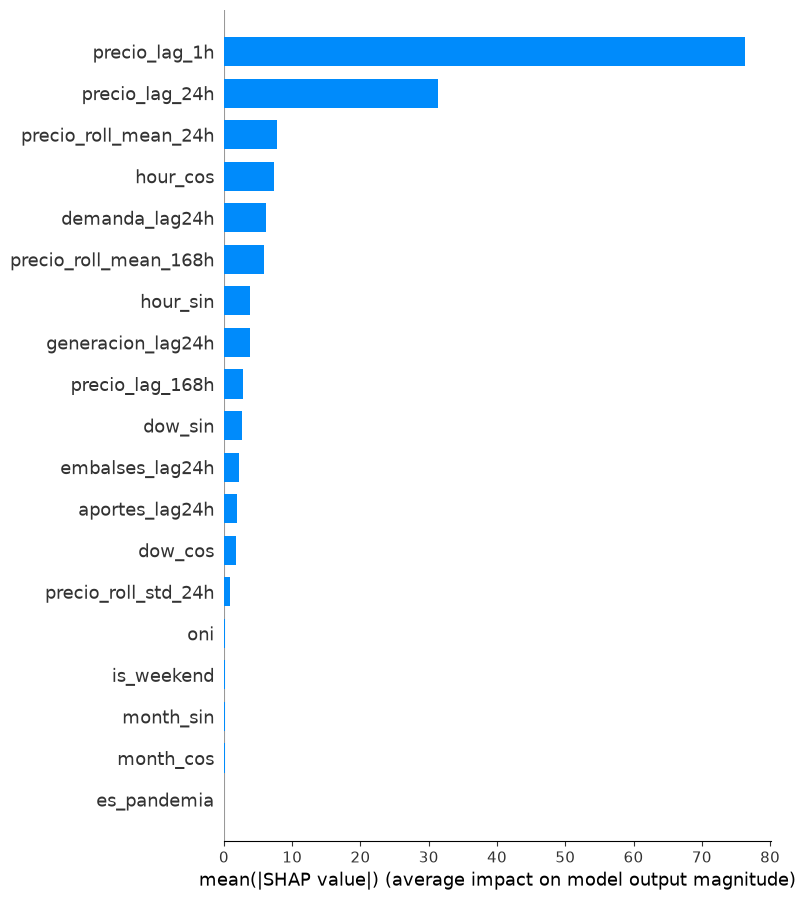

In [48]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)


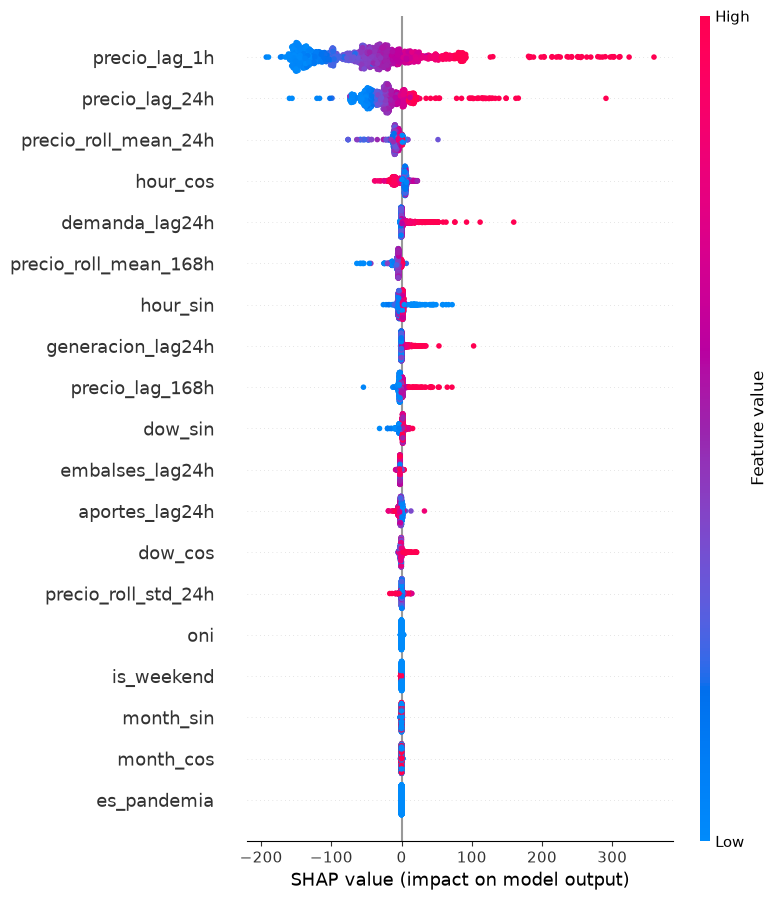

In [49]:
shap.summary_plot(shap_values, X_test, show=True)


## 9. Guardar resultados (para comparar con Prophet en Fase 3)

In [50]:
import os
os.makedirs("../data/processed/resultados", exist_ok=True)

pred_out = pd.DataFrame({
    "fecha_hora": y_test.index,
    "real": y_test.values,
    "xgboost_pred": y_pred,
})
pred_out.to_csv("../data/processed/resultados/xgboost_predicciones_holdout2025.csv", index=False)
results_df.to_csv("../data/processed/resultados/xgboost_metricas_holdout2025.csv")

model.save_model("../data/processed/resultados/xgboost_model.json")

print("Guardado en data/processed/resultados/")


Guardado en data/processed/resultados/


## Próximos pasos / preguntas abiertas

- [ ] Confirmar `COLUMN_MAP` contra las columnas reales del CSV.
- [ ] Confirmar decisión (3): ¿exógenas rezagadas (día-adelante honesto) o contemporáneas (solo explicativo)?
- [ ] Cuando se extienda el dataset a 2026: mover el holdout al tramo real ene-ago 2026 (TODO marcado en la sección 4).
- [ ] Si sobra tiempo: tuning de hiperparámetros (Optuna) — no bloqueante para tener un primer resultado comparable con Prophet.
- [ ] Una vez Prophet corra con datos reales: comparar `results_df` de ambos modelos con las mismas métricas (MAE/RMSE/MAPE) para decidir si el híbrido vale la pena (condicional, según el doc de estado).
